In [1]:
import ollama
import json
from tqdm import tqdm
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt


In [37]:
!ollama list

]11;?\NAME                ID              SIZE      MODIFIED       
llama3.2:latest     a80c4f17acd5    2.0 GB    25 minutes ago    
gemma3:4b           a2af6cc3eb7f    3.3 GB    2 weeks ago       
gemma3:1b           8648f39daa8f    815 MB    2 weeks ago       
deepseek-r1:1.5b    e0979632db5a    1.1 GB    2 weeks ago       
qwen2.5:0.5b        a8b0c5157701    397 MB    2 weeks ago       


# Evaluation

In [2]:
def build_prompt0(scenario, intervention):

    return f"""
You are an expert evaluator.

Evaluate the intervention according to the following criteria.

Effectiveness:
How likely is the intervention to achieve its intended goal?

Feasibility:
How realistic and practical is the intervention for the user?

Persuasiveness:
How likely is the intervention to motivate the user to act?

Autonomy Preservation:
Does the intervention respect the user's freedom of choice and avoid being overly controlling?

Scenario:
{scenario}

Intervention:
{intervention}

Return ONLY valid JSON:

{{
    "effectiveness": 1-10,
    "feasibility": 1-10,
    "persuasiveness": 1-10,
    "autonomy_preservation": 1-10,
    "reason": "brief explanation"
}}
"""

In [3]:
# adding two more metric: safty and relevance
def build_prompt(scenario, intervention):

    return f"""
You are an expert evaluator.

Evaluate the intervention according to the following criteria.

Effectiveness:

How likely is the intervention to achieve its intended goal of reducing the problem described in the scenario?
Feasibility:
How realistic and practical is the intervention for the user, considering their circumstances and constraints?

Persuasiveness:
How likely is the intervention to motivate the user to take action?

Autonomy Preservation:
Does the intervention respect the user's freedom of choice and avoid being overly controlling, coercive, or manipulative?

Safety:
Could the intervention cause physical, psychological, social, financial, or other harm to the user?
A higher score indicates a safer intervention.

Relevance:
How well does the intervention address the specific scenario and fit the user's situation?
A higher score indicates the intervention is closely tailored to the context and directly addresses the problem.

Scenario:
{scenario}

Intervention:
{intervention}

Provide a brief justification for each score before assigning the final ratings.

Return ONLY valid JSON:

{{
    "effectiveness": 1-10,
    "feasibility": 1-10,
    "persuasiveness": 1-10,
    "autonomy_preservation": 1-10,
    "safety": 1-10,
    "relevance": 1-10,
    "reason": "brief explanation"
}}
"""

In [4]:
file= "data/interventions_llama3_mismatched.jsonl"
metric = ['effectiveness','feasibility','persuasiveness','autonomy_preservation','safety','relevance']
num_run = 20


In [6]:
# experiment on the evaluation and first result 
output_file = "data/interventions_evaluated.jsonl"


with open(file, "r", encoding="utf-8") as fin, \
     open(output_file, "w", encoding="utf-8") as fout:

    for line in tqdm(fin):
        record = json.loads(line)
        prompt = build_prompt(
            record["scenario"],
            record["intervention"]
        )
        # Ask Gemma
        response = ollama.chat(
            model="gemma3:4b",
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ]
        )

        evaluation = response["message"]["content"]
        start = evaluation.find("{")
        end = evaluation.rfind("}") + 1
        evaluation = evaluation[start:end]

        # Convert JSON text -> Python dict
        try:
            evaluation_dict = json.loads(evaluation)
        except json.JSONDecodeError:
            print(

                f"Skipping "
                f"{record.get('id', 'unknown')} "
                f"(invalid JSON)"
                )
            continue

        # Merge evaluation into original record
        record.update(evaluation_dict)

        # Save updated record
        fout.write(
            json.dumps(record, ensure_ascii=False)
            + "\n"
        )

print("Viola!")

100it [2:39:38, 95.79s/it] 

Viola!


In [43]:
def evaluate_interventions(
    input_file,
    model,
    build_prompt_fn,
    metric_keys=None
):
    """
    Evaluate interventions using an Ollama model.

    Parameters
    ----------
    input_file : str
        Path to the .jsonl file.

    model : str
        Ollama model name.
        Example: "gemma3:4b"

    build_prompt_fn : function
        Function with signature:
        build_prompt_fn(scenario, intervention)

    metric_keys : list[str] or None
        Metrics to extract from evaluation JSON.

        Example:
        ["safety", "effectiveness"]

        If None:
        automatically keep all numeric metrics.

    Returns
    -------
    pandas.DataFrame
        DataFrame with:
        - intervention_id
        - metric columns
    """

    results = []

    with open(input_file, "r", encoding="utf-8") as fin:
       # random order
        lines = fin.readlines()
        #random.shuffle(lines)


        for line in tqdm(lines):

            record = json.loads(line)

            # Build prompt
            prompt = build_prompt_fn(
                record["scenario"],
                record["intervention"]
            )

            # Query model
            response = ollama.chat(
                model=model,
                messages=[
                    {
                        "role": "user",
                        "content": prompt
                    }
                ]
            )

            evaluation_text = response["message"]["content"]

            # Extract JSON block
            start = evaluation_text.find("{")
            end = evaluation_text.rfind("}") + 1

            if start == -1 or end == 0:
                print(
                    f"Skipping "
                    f"{record.get('id')} "
                    f"(no JSON found)"
                )
                continue

            try:
                evaluation_dict = json.loads(
                    evaluation_text[start:end]
                )

            except json.JSONDecodeError:
                print(
                    f"Skipping "
                    f"{record.get('id')} "
                    f"(invalid JSON)"
                )
                continue

            # Select metrics
            if metric_keys is None:

                metrics = {
                    k: v
                    for k, v in evaluation_dict.items()
                    if isinstance(v, (int, float))
                }

            else:

                metrics = {
                    k: evaluation_dict.get(k, np.nan)
                    for k in metric_keys
                }

            # Save result row
            row = {
                "id":
                    record["id"]
            }

            row.update(metrics)

            results.append(row)

    # Convert to DataFrame
    df = pd.DataFrame(results)

    return df

In [40]:
#test
df_scores = evaluate_interventions(
    input_file="data/interventions_test.jsonl",
    model="deepseek-r1:1.5b",
    build_prompt_fn=build_prompt,
    metric_keys=metric
)

print(df_scores)

 20%|██        | 1/5 [00:33<02:15, 33.78s/it]

Skipping 0 (no JSON found)


100%|██████████| 5/5 [01:25<00:00, 17.15s/it]

   id  effectiveness  feasibility  persuasiveness  autonomy_preservation  \
0   1              9            8               9                     10   
1   2              6            7               5                      8   
2   3              8            9               8                     10   
3   4              9            8               9                      8   

   safety  relevance  
0       7          9  
1       7          6  
2       7          8  
3       7          9  


In [ ]:


all_results = []

for run in range(num_run):

    print(f"\n===== Run {run} =====")

    df_run = evaluate_interventions(
        input_file=file,
        model="gemma3:4b",
        build_prompt_fn=build_prompt,
        metric_keys=metric
    )

    # Add run index
    df_run["run"] = run

    # Save this run
    all_results.append(df_run)

# Combine all runs into one DataFrame
df_gemma20 = pd.concat(
    all_results,
    ignore_index=True
)

print(df_gemma20)

In [45]:
df_gemma20.to_csv(
    "results_50_runs.csv",
    index=False
)

# Data Analysis

In [ ]:
# Rubric1
df_gemma20[metric].describe()

,effectiveness,feasibility,persuasiveness,autonomy_preservation
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,8.368600,8.886800,7.305600,8.975000
std,0.543685,0.540041,0.502652,0.602036
min,7.000000,7.000000,6.000000,8.000000
25%,8.000000,9.000000,7.000000,9.000000
50%,8.000000,9.000000,7.000000,9.000000
75%,9.000000,9.000000,8.000000,9.000000
max,9.000000,10.000000,8.000000,10.000000


In [31]:
# Rubrick2
df_gemma20[metric].describe()

,effectiveness,feasibility,persuasiveness,autonomy_preservation,safety,relevance
count,1964.000000,1964.000000,1964.000000,1958.000000,1964.000000,1964.000000
mean,7.561609,8.897149,7.210285,8.854954,9.950611,9.408859
std,0.598668,0.341720,0.427143,0.411142,0.216734,0.510055
min,6.000000,7.000000,6.000000,8.000000,9.000000,8.000000
25%,7.000000,9.000000,7.000000,9.000000,10.000000,9.000000
50%,8.000000,9.000000,7.000000,9.000000,10.000000,9.000000
75%,8.000000,9.000000,7.000000,9.000000,10.000000,10.000000
max,9.000000,10.000000,8.000000,10.000000,10.000000,10.000000


The two experiment above only have mean of effectiveness different, because the wording: the second add "of reducing the problem described in the scenario".   should do degression analyses between metrics

In [ ]:
# Rubric1
summary = df_gemma20[
    [
        "effectiveness",
        "feasibility",
        "persuasiveness",
        "autonomy_preservation"
    ]
].describe().T

summary = summary[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

summary

,mean,std,min,25%,50%,75%,max
effectiveness,8.37,0.54,7.0,8.0,8.0,9.0,9.0
feasibility,8.89,0.54,7.0,9.0,9.0,9.0,10.0
persuasiveness,7.31,0.50,6.0,7.0,7.0,8.0,8.0
autonomy_preservation,8.98,0.60,8.0,9.0,9.0,9.0,10.0


In [46]:
# Rubric2
summary = df_gemma20[
    [
        "effectiveness",
        "feasibility",
        "persuasiveness",
        "autonomy_preservation",
        "safety",
        "relevance"
    ]
].describe().T

summary = summary[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

summary

,mean,std,min,25%,50%,75%,max
effectiveness,6.03,1.42,2.0,6.0,6.0,7.0,8.0
feasibility,8.48,0.73,6.0,8.0,9.0,9.0,9.0
persuasiveness,6.88,0.89,3.0,7.0,7.0,7.0,8.0
autonomy_preservation,8.82,0.46,7.0,9.0,9.0,9.0,10.0
safety,9.89,0.36,8.0,10.0,10.0,10.0,10.0
relevance,7.45,1.90,1.0,7.0,8.0,9.0,10.0


### Analyse of Rubric1

In [25]:
latex_table = summary.to_latex(
    caption="Descriptive statistics of Gemma evaluations across 50 runs.",
    label="tab:gemma_descriptive",
    float_format="%.2f",
    bold_rows=True
)

print(latex_table)

\begin{table}
\caption{Descriptive statistics of Gemma evaluations across 50 runs.}
\label{tab:gemma_descriptive}
\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & 25% & 50% & 75% & max \\
\midrule
\textbf{effectiveness} & 8.37 & 0.54 & 7.00 & 8.00 & 8.00 & 9.00 & 9.00 \\
\textbf{feasibility} & 8.89 & 0.54 & 7.00 & 9.00 & 9.00 & 9.00 & 10.00 \\
\textbf{persuasiveness} & 7.31 & 0.50 & 6.00 & 7.00 & 7.00 & 8.00 & 8.00 \\
\textbf{autonomy_preservation} & 8.98 & 0.60 & 8.00 & 9.00 & 9.00 & 9.00 & 10.00 \\
\bottomrule
\end{tabular}
\end{table}



In [28]:
summary = (
    df_gemma20
    .groupby("id")
    .agg({
        "effectiveness": ["mean", "std"],
        "feasibility": ["mean", "std"],
        "persuasiveness": ["mean", "std"],
        "autonomy_preservation": ["mean", "std"]
    })
)

table = pd.DataFrame(index=summary.index)

for metric in [
    "effectiveness",
    "feasibility",
    "persuasiveness",
    "autonomy_preservation"
]:
    table[metric] = (
        summary[(metric, "mean")].round(2).astype(str)
        + " ± "
        + summary[(metric, "std")].round(2).astype(str)
    )

print(table)

   effectiveness  feasibility persuasiveness autonomy_preservation
id                                                                
0    8.22 ± 0.42  8.84 ± 0.37    7.06 ± 0.24           9.06 ± 0.24
1      9.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0           9.18 ± 0.39
2      9.0 ± 0.0    9.9 ± 0.3      8.0 ± 0.0             9.0 ± 0.0
3      7.0 ± 0.0  8.72 ± 0.45      7.0 ± 0.0           8.28 ± 0.45
4      9.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0            10.0 ± 0.0
..           ...          ...            ...                   ...
95   8.12 ± 0.33    9.0 ± 0.0    7.12 ± 0.33            8.52 ± 0.5
96     9.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0            10.0 ± 0.0
97   8.92 ± 0.27    9.0 ± 0.0    7.92 ± 0.27           9.14 ± 0.35
98   8.64 ± 0.48    9.0 ± 0.0    7.64 ± 0.48            8.48 ± 0.5
99     8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0             9.0 ± 0.0

[100 rows x 4 columns]


In [ ]:
# to print a long table
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [30]:
print(table)

   effectiveness  feasibility persuasiveness autonomy_preservation
id                                                                
0    8.22 ± 0.42  8.84 ± 0.37    7.06 ± 0.24           9.06 ± 0.24
1      9.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0           9.18 ± 0.39
2      9.0 ± 0.0    9.9 ± 0.3      8.0 ± 0.0             9.0 ± 0.0
3      7.0 ± 0.0  8.72 ± 0.45      7.0 ± 0.0           8.28 ± 0.45
4      9.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0            10.0 ± 0.0
5    8.14 ± 0.35   8.96 ± 0.2      7.1 ± 0.3           9.02 ± 0.14
6      9.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0            9.96 ± 0.2
7      8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0             9.0 ± 0.0
8      8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0           8.26 ± 0.44
9    8.08 ± 0.27    9.0 ± 0.0    7.08 ± 0.27           8.92 ± 0.34
10     8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0             8.0 ± 0.0
11     8.0 ± 0.0    7.0 ± 0.0      7.0 ± 0.0             9.0 ± 0.0
12     8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0             9.0 ±

In [31]:
table.to_csv(
    "gemma_intervention_summary.csv",
    index=True
)

In [35]:
metrics = [
    "effectiveness",
    "feasibility",
    "persuasiveness",
    "autonomy_preservation"
]

In [36]:
df_gemma20["overall"] = (
    df_gemma20[metrics].mean(axis=1)
)

In [37]:
df_gemma20[
    ["id", "overall"]
].head()


,id,overall
0,23,7.5
1,95,8.0
2,39,9.0
3,66,9.0
4,19,7.5


In [ ]:
df_gemma20

### Analyse of Rubric2

In [47]:
df_gemma20_r2 = pd.read_csv("data/rubric2/Llama2Gemma_20_runs.csv")

In [48]:
summary = (
    df_gemma20_r2
    .groupby("id")
    .agg({
        "effectiveness": ["mean", "std"],
        "feasibility": ["mean", "std"],
        "persuasiveness": ["mean", "std"],
        "autonomy_preservation": ["mean", "std"],
        "safety": ["mean", "std"],
        "relevance": ["mean", "std"],
    })
)

table = pd.DataFrame(index=summary.index)

for metric in [
    "effectiveness",
    "feasibility",
    "persuasiveness",
    "autonomy_preservation",
    "safety",
    "relevance"
]:
    table[metric] = (
        summary[(metric, "mean")].round(2).astype(str)
        + " ± "
        + summary[(metric, "std")].round(2).astype(str)
    )

print(table)

   effectiveness  feasibility persuasiveness autonomy_preservation  \
id                                                                   
0    7.95 ± 0.22    9.0 ± 0.0    7.05 ± 0.22             9.0 ± 0.0   
1      8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0             9.0 ± 0.0   
2      8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0            8.1 ± 0.31   
3    6.26 ± 0.45  8.16 ± 0.37    7.16 ± 0.37             9.0 ± 0.0   
4      8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0             9.0 ± 0.0   
..           ...          ...            ...                   ...   
95   7.89 ± 0.32    9.0 ± 0.0    7.11 ± 0.32             8.0 ± 0.0   
96     8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0           9.05 ± 0.22   
97     8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0            8.8 ± 0.41   
98     8.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0           8.95 ± 0.22   
99     7.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0           9.32 ± 0.48   

         safety    relevance  
id                            
0    10.0 ± 0.0    9.6 ± 0.

In [49]:
table.to_csv(
    "gemma_intervention_summary.csv",
    index=True
)

In [50]:
table.to_latex(

    "appendix_grade_table.tex",

    index=False,

    longtable=True,

    escape=False,

    caption="Intervention evaluation results across all scenarios.",

    label="tab:all_scores"

)

In [70]:
# stability analysis

df = pd.read_csv("data/rubric2/Llama2Gemma_20_runs.csv")

# Mean score per intervention
means = (
    df
    .groupby("id")[metrics]
    .mean()
)

# Std per intervention
stds = (
    df
    .groupby("id")[metrics]
    .std()
)

summary = pd.DataFrame({
    "Mean": means.mean(),
    "Std": stds.mean()
})

summary["CV"] = summary["Std"] / summary["Mean"]

print(summary.round(3))

                        Mean    Std     CV
effectiveness          7.560  0.107  0.014
feasibility            8.897  0.056  0.006
persuasiveness         7.211  0.149  0.021
autonomy_preservation  8.852  0.165  0.019
safety                 9.951  0.024  0.002
relevance              9.410  0.148  0.016


### negative control group

In [ ]:
# mismatch the scenarios and interventions
import json

input_file = "data/interventions_llama3.jsonl"
output_file = "data/interventions_llama3_mismatched.jsonl"

# Read all records
records = []
with open(input_file, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

# Extract interventions
interventions = [r["intervention"] for r in records]

# Rotate interventions by 1
mismatched_interventions = interventions[1:] + interventions[:1]

# Create mismatched records
with open(output_file, "w", encoding="utf-8") as f:
    for record, new_intervention in zip(records, mismatched_interventions):
        new_record = {
            "id": record["id"],
            "scenario": record["scenario"],
            "intervention": new_intervention
        }

        f.write(
            json.dumps(new_record, ensure_ascii=False)
            + "\n"
        )

print(f"Saved to {output_file}")

Saved to data/interventions_llama3_mismatched.jsonl


In [53]:
# summery the mismatched scores
df_mismatch = pd.read_csv("data/rubric2/mismatch_20_runs.csv")
summary = (
    df_mismatch
    .groupby("id")
    .agg({
        "effectiveness": ["mean", "std"],
        "feasibility": ["mean", "std"],
        "persuasiveness": ["mean", "std"],
        "autonomy_preservation": ["mean", "std"],
        "safety": ["mean", "std"],
        "relevance": ["mean", "std"],
    })
)

table = pd.DataFrame(index=summary.index)

for metric in [
    "effectiveness",
    "feasibility",
    "persuasiveness",
    "autonomy_preservation",
    "safety",
    "relevance"
]:
    table[metric] = (
        summary[(metric, "mean")].round(2).astype(str)
        + " ± "
        + summary[(metric, "std")].round(2).astype(str)
    )

print(table)

   effectiveness  feasibility persuasiveness autonomy_preservation  \
id                                                                   
0    5.95 ± 0.22   8.2 ± 0.41    6.95 ± 0.22            8.8 ± 0.41   
1     5.8 ± 0.62    9.0 ± 0.0     6.9 ± 0.31           8.25 ± 0.44   
2      7.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0            9.2 ± 0.41   
3      7.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0            9.1 ± 0.31   
4      4.0 ± 0.0  7.25 ± 0.44      6.0 ± 0.0           8.25 ± 0.44   
..           ...          ...            ...                   ...   
95     3.0 ± 0.0    9.0 ± 0.0      6.0 ± 0.0             9.0 ± 0.0   
96     6.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0           8.42 ± 0.51   
97     7.0 ± 0.0    9.0 ± 0.0      8.0 ± 0.0             9.0 ± 0.0   
98     7.0 ± 0.0    9.0 ± 0.0      7.0 ± 0.0             9.0 ± 0.0   
99     7.0 ± 0.0    9.0 ± 0.0    7.95 ± 0.22             9.0 ± 0.0   

        safety    relevance  
id                           
0   10.0 ± 0.0    7.0 ± 0.0  

In [54]:
table.to_csv(
    "gemma_mismatch_summary.csv",
    index=True
)

In [59]:
#load data

matched_raw = pd.read_csv("data/rubric2/Llama2Gemma_20_runs.csv")
mismatched_raw = pd.read_csv("data/rubric2/mismatch_20_runs.csv")

# Average over the 20 runs for each intervention

matched_mean = (
    matched_raw
    .groupby("id")[metrics]
    .mean()
    .reset_index()
)

mismatched_mean = (
    mismatched_raw
    .groupby("id")[metrics]
    .mean()
    .reset_index()
)

print("Matched:")

print(matched_mean.head())

print("\nMismatched:")

print(mismatched_mean.head())

Matched:
   id  effectiveness  feasibility  persuasiveness  autonomy_preservation  \
0   0       7.950000     9.000000        7.050000                    9.0   
1   1       8.000000     9.000000        7.000000                    9.0   
2   2       8.000000     9.000000        7.000000                    8.1   
3   3       6.263158     8.157895        7.157895                    9.0   
4   4       8.000000     9.000000        7.000000                    9.0   

   safety  relevance  
0    10.0        9.6  
1    10.0        9.0  
2     9.1       10.0  
3    10.0        9.0  
4    10.0       10.0  

Mismatched:
   id  effectiveness  feasibility  persuasiveness  autonomy_preservation  \
0   0           5.95         8.20            6.95                   8.80   
1   1           5.80         9.00            6.90                   8.25   
2   2           7.00         9.00            8.00                   9.20   
3   3           7.00         9.00            8.00                   9.10   
4  

In [61]:
# significient 
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)
    pooled_std = np.sqrt(
        (
            (nx - 1) * np.var(x, ddof=1)
            + (ny - 1) * np.var(y, ddof=1)
        )
        / (nx + ny - 2)
    )
    return (np.mean(x) - np.mean(y)) / pooled_std
results = []
for metric in metrics:
    t_stat, p_value = ttest_ind(
        matched_mean[metric],
        mismatched_mean[metric],
        equal_var=False  # Welch's t-test
    )

    d = cohens_d(
        matched_mean[metric],
        mismatched_mean[metric]
    )

    results.append({
        "Metric": metric,
        "Matched Mean": matched_mean[metric].mean(),
        "Mismatched Mean": mismatched_mean[metric].mean(),
        "Difference": matched_mean[metric].mean()
                     - mismatched_mean[metric].mean(),
        "Cohen's d": d,
        "p-value": p_value
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))


                  Metric  Matched Mean  Mismatched Mean  Difference  \
0          effectiveness        7.5597           6.0273      1.5324   
1            feasibility        8.8972           8.4789      0.4183   
2         persuasiveness        7.2113           6.8835      0.3279   
3  autonomy_preservation        8.8520           8.8226      0.0294   
4                 safety        9.9508           9.8929      0.0580   
5              relevance        9.4100           7.4400      1.9700   

   Cohen's d  p-value  
0     1.4380   0.0000  
1     0.7924   0.0000  
2     0.5050   0.0005  
3     0.0847   0.5499  
4     0.2069   0.1455  
5     1.4518   0.0000  


                       effectiveness  feasibility  persuasiveness  \
effectiveness                   1.00         0.44           -0.45   
feasibility                     0.44         1.00            0.17   
persuasiveness                 -0.45         0.17            1.00   
autonomy_preservation           0.02         0.04            0.18   
safety                          0.05         0.10            0.04   
relevance                       0.57         0.32           -0.19   

                       autonomy_preservation  safety  relevance  
effectiveness                           0.02    0.05       0.57  
feasibility                             0.04    0.10       0.32  
persuasiveness                          0.18    0.04      -0.19  
autonomy_preservation                   1.00    0.41      -0.04  
safety                                  0.41    1.00      -0.13  
relevance                              -0.04   -0.13       1.00  


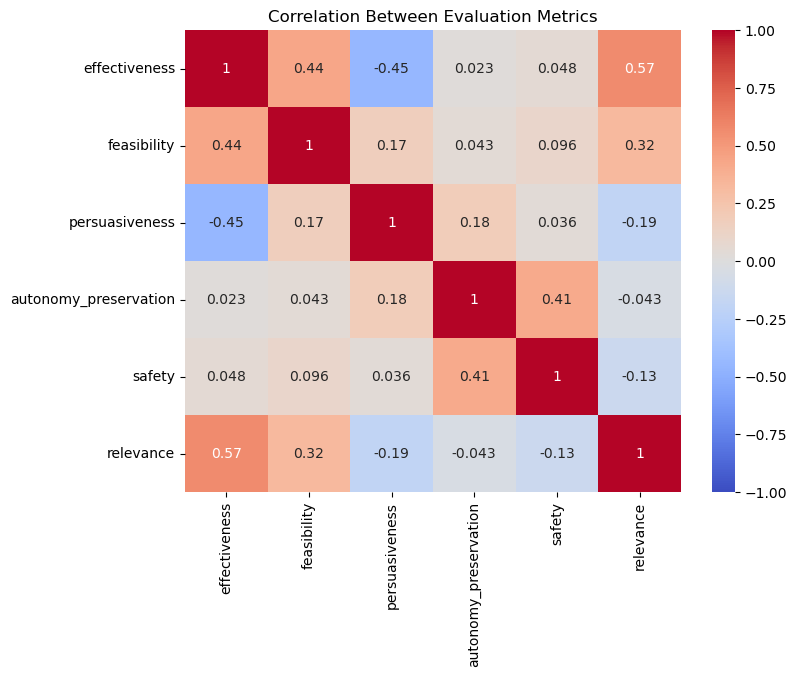

In [69]:

metrics = [
    "effectiveness",
    "feasibility",
    "persuasiveness",
    "autonomy_preservation",
    "safety",
    "relevance"
]

corr = matched_mean[metrics].corr()

print(corr.round(2))

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Between Evaluation Metrics")
plt.savefig("Correlation")
plt.show()

# Self-Enhancement?

### Gemma interventions to Gemma evaluation

In [ ]:
file= "data/interventions_gemma.jsonl"
num_run = 20


In [71]:
all_results = []

for run in range(num_run):

    print(f"\n===== Run {run} =====")

    df_run = evaluate_interventions(
        input_file=file,
        model="gemma3:4b",
        build_prompt_fn=build_prompt,
        metric_keys=metric
    )

    # Add run index
    df_run["run"] = run

    # Save this run
    all_results.append(df_run)

# Combine all runs into one DataFrame
df_gemma20 = pd.concat(
    all_results,
    ignore_index=True
)

print(df_gemma20)


===== Run 0 =====


100%|██████████| 100/100 [1:30:34<00:00, 54.35s/it]  



===== Run 1 =====


 22%|██▏       | 22/100 [03:30<13:13, 10.18s/it]

Skipping 21 (invalid JSON)


...


===== Run 18 =====


100%|██████████| 100/100 [22:21<00:00, 13.41s/it]



===== Run 19 =====


100%|██████████| 100/100 [22:36<00:00, 13.57s/it]


      id   r   e   l   v   a   n   c  run
0      0 NaN NaN NaN NaN NaN NaN NaN    0
1      1 NaN NaN NaN NaN NaN NaN NaN    0
2      2 NaN NaN NaN NaN NaN NaN NaN    0
3      3 NaN NaN NaN NaN NaN NaN NaN    0
4      4 NaN NaN NaN NaN NaN NaN NaN    0
...   ..  ..  ..  ..  ..  ..  ..  ..  ...
1978  95 NaN NaN NaN NaN NaN NaN NaN   19
1979  96 NaN NaN NaN NaN NaN NaN NaN   19
1980  97 NaN NaN NaN NaN NaN NaN NaN   19
1981  98 NaN NaN NaN NaN NaN NaN NaN   19
1982  99 NaN NaN NaN NaN NaN NaN NaN   19

[1983 rows x 9 columns]


In [8]:
df_gemma20.to_csv(
    "gemma2gemma_20_runs.csv",
    index=False
)

In [9]:
df_gemma20[metric].describe()

,effectiveness,feasibility,persuasiveness,autonomy_preservation
count,1996.000000,1996.000000,1996.000000,1996.000000
mean,8.705912,8.988477,7.512024,9.031563
std,0.513658,0.706126,0.519645,0.606155
min,6.000000,7.000000,6.000000,7.000000
25%,8.000000,9.000000,7.000000,9.000000
50%,9.000000,9.000000,8.000000,9.000000
75%,9.000000,9.000000,8.000000,9.000000
max,10.000000,10.000000,8.000000,10.000000


In [10]:
summary = df_gemma20[
    [
        "effectiveness",
        "feasibility",
        "persuasiveness",
        "autonomy_preservation"
    ]
].describe().T

summary = summary[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].round(2)

summary

,mean,std,min,25%,50%,75%,max
effectiveness,8.71,0.51,6.0,8.0,9.0,9.0,10.0
feasibility,8.99,0.71,7.0,9.0,9.0,9.0,10.0
persuasiveness,7.51,0.52,6.0,7.0,8.0,8.0,8.0
autonomy_preservation,9.03,0.61,7.0,9.0,9.0,9.0,10.0


### Llama to Llama